In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# === Paths to datasets ===
original_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/original-data-splits"
filtered_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_1"
reu_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2"
meta_cols = ['molecule_chembl_id', 'canonical_smiles', 'activity_class', 'pIC50']

In [5]:
targets = ["5-HT6","ache", "bace1", "buche","esr1","gsk-3beta", "mao-b"]

In [6]:
# === Collect feature counts ===
feature_counts = []


for target in targets:
    try:
        df_orig = pd.read_csv(os.path.join(original_path, f"{target}_original_split_train.csv"))
        df_filtered = pd.read_csv(os.path.join(filtered_path, f"{target}_feature_filtered_1_train.csv"))
        df_reu = pd.read_csv(os.path.join(reu_path, f"{target}_train_reu.csv"))

        count_orig = df_orig.shape[1] - len(meta_cols)
        count_filtered = df_filtered.shape[1] - len(meta_cols)
        count_reu = df_reu.shape[1] - len(meta_cols)

        feature_counts.append({"Target": target.upper(), "Set": "Original", "Features": count_orig})
        feature_counts.append({"Target": target.upper(), "Set": "Filtered", "Features": count_filtered})
        feature_counts.append({"Target": target.upper(), "Set": "RFECV", "Features": count_reu})

    except FileNotFoundError:
        print(f" Files missing for target: {target}")
        continue






In [7]:
# === Convert to DataFrame ===
df_counts = pd.DataFrame(feature_counts)

df_counts.head()

,Target,Set,Features
0,5-HT6,Original,2264
1,5-HT6,Filtered,760
2,5-HT6,RFECV,550
3,ACHE,Original,2264
4,ACHE,Filtered,906


In [8]:
# === Save results ===




results_out = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/no_of_featuresin each dataset.csv"
df_counts.to_csv(results_out, index=False)

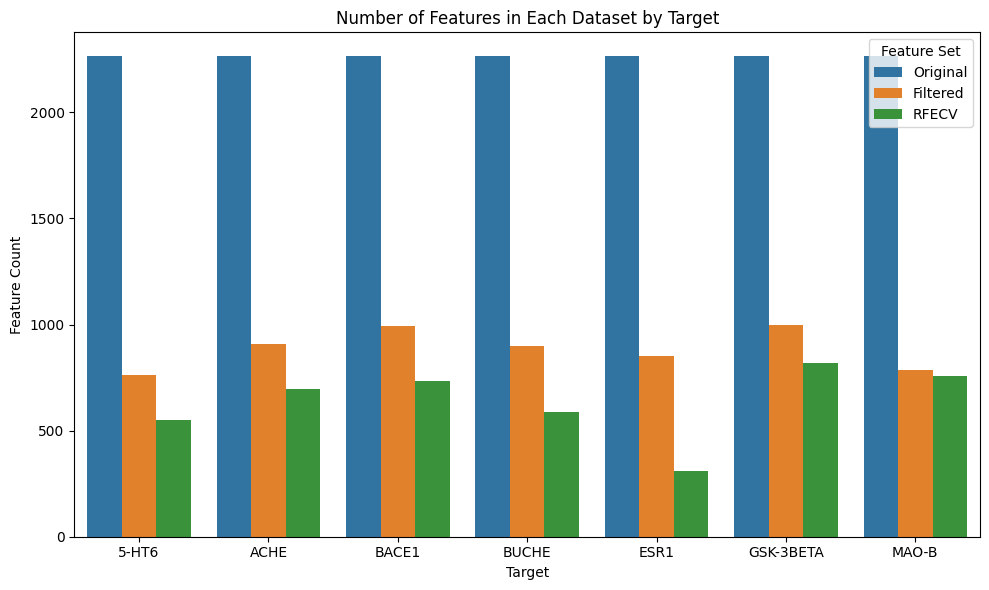

In [9]:
# === Plot ===

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x="Target", y="Features", hue="Set")
plt.title("Number of Features in Each Dataset by Target")
plt.ylabel("Feature Count")
plt.xlabel("Target")
plt.legend(title="Feature Set")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/feature_counts_comparison.png", dpi=300)
plt.show()

Feature Count and Reduction Percentage:
  Target  Original  Filtered  Filtered (%)  REU  REU (%)
0  5-HT6      2264       760          33.6  550     24.3
1   AChE      2264       906          40.0  696     30.7
2  BACE1      2264       992          43.8  732     32.3
3  BuChE      2264       898          39.7  588     26.0
4   ESR1      2264       852          37.6  312     13.8
5  GSK3β      2264      1000          44.2  820     36.2
6  MAO-B      2264       786          34.7  756     33.4


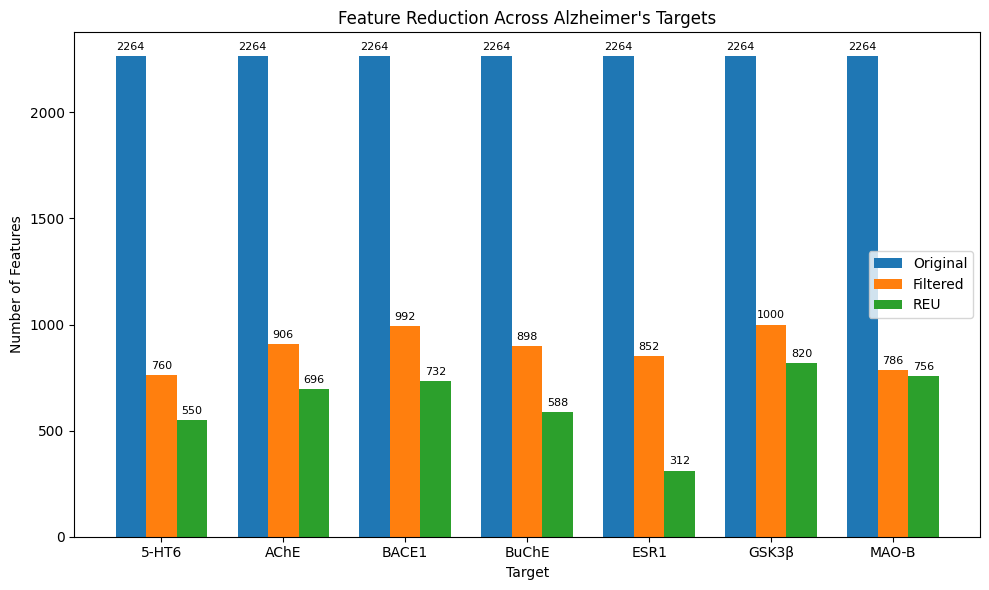

In [10]:
import numpy as np

# === Step 1: Feature counts per target ===
data = {
    "Target": ["5-HT6", "AChE", "BACE1", "BuChE", "ESR1", "GSK3β", "MAO-B"],
    "Original": [2264] * 7,
    "Filtered": [760, 906, 992, 898, 852, 1000, 786],
    "REU": [550, 696, 732, 588, 312, 820, 756]
}

df = pd.DataFrame(data)

# === Step 2: Calculate percentage of original retained ===
df["Filtered (%)"] = (df["Filtered"] / df["Original"] * 100).round(1)
df["REU (%)"] = (df["REU"] / df["Original"] * 100).round(1)

# === Step 3: Display table ===
print("Feature Count and Reduction Percentage:")
print(df[["Target", "Original", "Filtered", "Filtered (%)", "REU", "REU (%)"]])

# === Step 4: Plot grouped bar chart ===
x = np.arange(len(df))  # the label locations
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(x - width, df["Original"], width, label="Original")
bar2 = ax.bar(x, df["Filtered"], width, label="Filtered")
bar3 = ax.bar(x + width, df["REU"], width, label="REU")

# Add labels and title
ax.set_xlabel("Target")
ax.set_ylabel("Number of Features")
ax.set_title("Feature Reduction Across Alzheimer's Targets")
ax.set_xticks(x)
ax.set_xticklabels(df["Target"])
ax.legend()

# Annotate bars with counts
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

annotate_bars(bar1)
annotate_bars(bar2)
annotate_bars(bar3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/feature_reduction_comparison.png", dpi=300)
plt.show()
